# mechanism_viewer examples

## Use a plot similar to UpSet for missing patterns
This notebook contains examples of how to use `upset_missing_rows()` from `viewer_upset.py` to inspect how many rows share the same missing-value pattern across columns.

### 1. Generate a synthetic dataset with missing values

For this example, a dataset with one complete column and four columns with mixed missingness mechanisms is generated.

In [1]:
from mechanism_viewer import generate_dataset_with_missingness, ColType

data = generate_dataset_with_missingness(200, [ColType.DISCRETE, ColType.CONTINUOUS, ColType.CONTINUOUS,
                                                ColType.BINARY], 1, ["MCAR", "MAR", "MCAR"], [0.4, 0.2, 0.4])

display(data.head(10))

,Col1,Col2,Col3,Col4
0,8,-1.507326,NaN,1
1,7,-0.985158,-0.379687,1
2,7,-0.860842,0.376948,<NA>
3,2,2.457424,-1.126988,0
4,6,1.801742,1.328631,1
5,3,-0.411749,1.245635,0
6,8,-0.363583,NaN,0
7,3,NaN,-1.514755,1
8,7,-1.908130,NaN,1
9,8,NaN,NaN,0


### 2. Plot the number of rows with similar missing patterns

The function `upset_missing_rows()` can be used to create a bar plot similar to UpSet, where each bar represents a group of columns that have the same rows with missing values. The value of each bar is the number of rows that have missing values in the same columns.

This function returns a `(figure, axis)` tuple, so that the user can adapt the plot to their wish. In addition, by setting `display_plot=True`, the function will also display the plot inside the notebook.

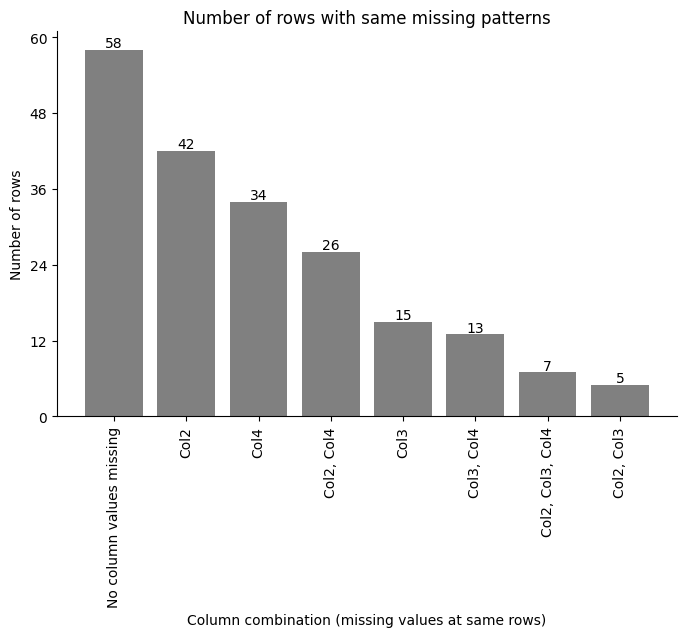

In [2]:
from mechanism_viewer import upset_missing_rows

fig_similar_miss, ax_similar_miss = upset_missing_rows(data, display_plot=True)

In addition, the function allows specifying a limit on how many bars are displayed. The parameter ``min_rows_display`` ensures that only bars with at least the specified minimum number of rows appear in the plot.

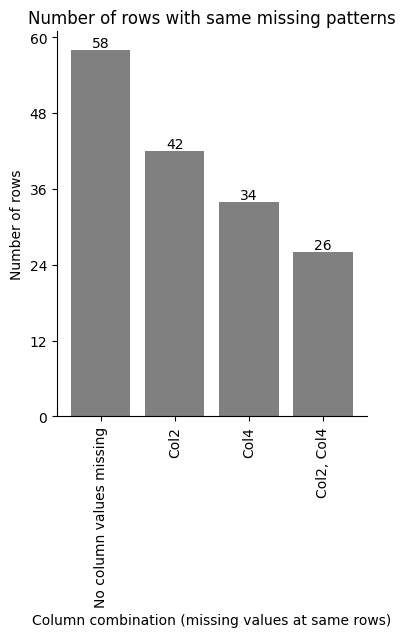

In [8]:
fig_similar_miss, ax_similar_miss = upset_missing_rows(data, min_rows_display=20, display_plot=True)

> Note: This visualization is descriptive and useful for pattern discovery. It should be used together with other tests to infer the most likely missing data mechanism of the columns.